# Weekly project 6
Today we will continue work from monday.
We will follow the style of last week.

Weekly project:
- You will need to implement your own k-means algorithm. You are not allowed to use the implementation in `sklearn`.
- It should be able to cluster each of the different figures.
- Extend your k-means so it finds the optimal amount of clusters.
  
## Challenge
- Implement the mean shift clustering algorithm


In [18]:
import numpy as np
import open3d as o3d
import copy
import matplotlib.pyplot as plt

def draw_labels_on_model(pcl, labels):
    cmap = plt.get_cmap("tab20")
    pcl_temp = copy.deepcopy(pcl)
    max_label = labels.max()
    colors = cmap(labels / (max_label if max_label > 0 else 1))
    colors[labels < 0] = 0
    pcl_temp.colors = o3d.utility.Vector3dVector(colors[:, :3])
    o3d.visualization.draw_geometries([pcl_temp])

d = 4
mesh = o3d.geometry.TriangleMesh.create_tetrahedron().translate((-d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_octahedron().translate((0, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_icosahedron().translate((d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_torus().translate((-d, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=1).translate((0, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=2).translate((d, -d, 0))

## apply k means on this
point_cloud = mesh.sample_points_uniformly(int(1e3))

k=2, best silhouette=0.5913
k=3, best silhouette=0.5150
k=4, best silhouette=0.5191
k=5, best silhouette=0.5187
k=6, best silhouette=0.5240
k=7, best silhouette=0.4659
k=8, best silhouette=0.4739
k=9, best silhouette=0.4764
k=10, best silhouette=0.4285
Best k: 2


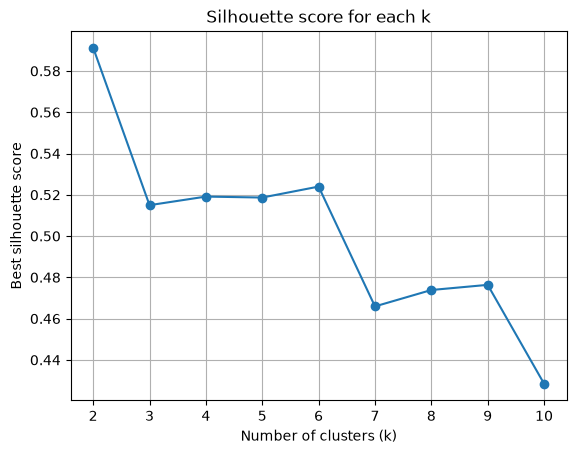

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scores = []

# initialize the centroids with random values of each feature
def random_centroids(data, k):
    centroids = []
    for i in range(k):
        centroid = data.apply(lambda x: float(x.sample().iloc[0]))
        centroids.append(centroid)
        # every centroid is a pandas series
        # this command combines all these series into 1 dataframe
    return pd.concat(centroids, axis=1)


def get_labels(data, centroids):
    # for each data point, we subtract the centroid
    distances = centroids.apply(
        lambda x: np.sqrt(((data - x) ** 2).sum(axis=1))
    )
    # finds the index of the minimum value of each row
    # which means which cluster each data point should be in
    return distances.idxmin(axis=1)


def new_centroids(data, labels, k):
    # for each label we create one group per cluster
    # calculates the new center of each column
    centroids = data.groupby(labels).mean().T
    centroids = centroids.reindex(columns=range(k))

    # reinitialize any empty clusters
    for i in range(k):
        if centroids[i].isna().any():
            centroids[i] = data.sample(1).iloc[0]

    return centroids


def kmeans(data, k, max_iterations=100):
    """Group data into k clusters.

    Args:
        data (pd.DataFrame): Numeric feature data, already scaled if needed.
        k (int): Number of clusters.
        max_iterations (int): Maximum number of iterations.

    Returns:
        centroids (pd.DataFrame): Each column is a cluster centroid.
        labels (pd.Series): Cluster assigned to each data point.
    """
    centroids = random_centroids(data, k)
    old_centroids = pd.DataFrame()
    iteration = 1

    while iteration <= max_iterations and not centroids.equals(old_centroids):
        old_centroids = centroids

        labels = get_labels(data, centroids)
        centroids = new_centroids(data, labels, k)
        iteration += 1

    # get labels using the final centroids
    labels = get_labels(data, centroids)

    return centroids, labels

# Convert the Open3D point cloud to a pandas DataFrame
data = pd.DataFrame(
    np.asarray(point_cloud.points),
    columns=["x", "y", "z"]
)

best_score = -np.inf
scores = []

for k in range(2, 11):
    best_score_for_k = -np.inf

    for repeat in range(10):
        current_centroids, current_labels = kmeans(data, k)

        score = silhouette_score(
            data, current_labels,
            sample_size=min(2000, len(data)),
            random_state=42
        )

        if score > best_score_for_k:
            best_score_for_k = score

        if score > best_score:
            best_score = score
            best_k = k
            centroids = current_centroids
            labels = current_labels

    # Outside the repeat loop: save ONE score per k
    scores.append(best_score_for_k)
    print(f"k={k}, best silhouette={best_score_for_k:.4f}")

print("Best k:", best_k)

plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Best silhouette score")
plt.title("Silhouette score for each k")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

draw_labels_on_model(point_cloud, labels.to_numpy())